In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("customer_dataset.csv")

In [4]:
df.head()

,Customer_ID,Age,Gender,Annual_Income,Purchase_Amount,Purchase_Frequency,Customer_Rating
0,C0001,42,Female,64100,132.82,2,2.4
1,C0002,26,Male,44400,187.22,12,4.6
2,C0003,47,Male,71000,118.11,5,4.3
3,C0004,49,Male,78700,190.41,9,2.0
4,C0005,18,Male,38100,150.80,7,4.6


## Finding information about the dataset.

In [5]:
df.describe()

,Age,Annual_Income,Purchase_Amount,Purchase_Frequency,Customer_Rating
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.000000
mean,38.020000,70135.400000,184.329673,5.748667,3.475400
std,11.403199,34173.004399,93.531508,2.604231,0.783103
min,18.000000,16700.000000,21.470000,1.000000,1.000000
25%,30.000000,46200.000000,118.665000,4.000000,2.900000
50%,38.000000,63100.000000,165.325000,6.000000,3.500000
75%,45.250000,84800.000000,226.712500,7.000000,4.000000
max,70.000000,250000.000000,839.020000,18.000000,5.000000


In [6]:
df.isna().sum()

Customer_ID           0
Age                   0
Gender                0
Annual_Income         0
Purchase_Amount       0
Purchase_Frequency    0
Customer_Rating       0
dtype: int64

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         1500 non-null   str    
 1   Age                 1500 non-null   int64  
 2   Gender              1500 non-null   str    
 3   Annual_Income       1500 non-null   int64  
 4   Purchase_Amount     1500 non-null   float64
 5   Purchase_Frequency  1500 non-null   int64  
 6   Customer_Rating     1500 non-null   float64
dtypes: float64(2), int64(3), str(2)
memory usage: 96.8 KB


## Trying to find duplicated rows in data.

In [8]:
df[df.duplicated()]

,Customer_ID,Age,Gender,Annual_Income,Purchase_Amount,Purchase_Frequency,Customer_Rating


There wasnt any duplicated row.

## Finding outliers in dataset.

In [9]:
def find_outliers_iqr(data):
    outliers=[]
    q1,q3=np.percentile(data,[25,75])
    iqr=q3-q1
    higher_fence=q3+(1.5*iqr)
    lower_fence=q1-(1.5*iqr)
    for i in data:
        if i > higher_fence or i<lower_fence:
            outliers.append(i)
    return outliers

In [10]:
def find_outliers_z(data):
    mean=np.mean(data)
    std=np.std(data)
    outliers=[]
    for i in data:
        z_score=(i-mean)/std
        if z_score>3 or z_score<-3:
            outliers.append(i)
    return outliers

In [11]:
find_outliers_iqr(df["Annual_Income"])

[172800,
 174700,
 175300,
 181500,
 169700,
 203200,
 146800,
 176500,
 159000,
 247300,
 159700,
 217800,
 156700,
 147600,
 145400,
 153000,
 239200,
 250000,
 160800,
 175000,
 168500,
 154600,
 165700,
 150000,
 166200,
 163400,
 184300,
 160800,
 148800,
 143200,
 152500,
 178100,
 250000,
 227600,
 146800,
 156700,
 175300,
 185900,
 146100,
 164700,
 217200,
 201400,
 191400,
 175600,
 149000,
 160300,
 181100,
 250000,
 174600,
 148900,
 250000,
 143300,
 187500,
 230600,
 151600,
 197500,
 193700]

In [12]:
find_outliers_z(df["Annual_Income"])

[172800,
 174700,
 175300,
 181500,
 203200,
 176500,
 247300,
 217800,
 239200,
 250000,
 175000,
 184300,
 178100,
 250000,
 227600,
 175300,
 185900,
 217200,
 201400,
 191400,
 175600,
 181100,
 250000,
 174600,
 250000,
 187500,
 230600,
 197500,
 193700]

In [13]:
len(find_outliers_iqr(df["Annual_Income"]))

57

In [14]:
len(find_outliers_z(df["Annual_Income"]))

29

In [15]:
find_outliers_iqr(df["Purchase_Amount"])

[519.32,
 593.17,
 519.13,
 582.32,
 460.84,
 440.0,
 555.48,
 408.73,
 624.9,
 520.18,
 492.76,
 394.95,
 839.02,
 431.37,
 610.55,
 441.62,
 413.18,
 421.6,
 415.26,
 398.24,
 412.25,
 587.22,
 405.02,
 586.84,
 429.96,
 417.98,
 412.12,
 435.84,
 717.78,
 516.28,
 487.92,
 399.73,
 520.32,
 388.88,
 526.98,
 445.82,
 479.27,
 423.9,
 401.12,
 559.26,
 456.64,
 392.0,
 534.0,
 415.01,
 476.15,
 421.52,
 729.57,
 440.43,
 436.21,
 488.86,
 409.09,
 496.03,
 568.04]

In [16]:
find_outliers_z(df["Purchase_Amount"])

[519.32,
 593.17,
 519.13,
 582.32,
 555.48,
 624.9,
 520.18,
 492.76,
 839.02,
 610.55,
 587.22,
 586.84,
 717.78,
 516.28,
 487.92,
 520.32,
 526.98,
 479.27,
 559.26,
 534.0,
 476.15,
 729.57,
 488.86,
 496.03,
 568.04]

In [17]:
len(find_outliers_iqr(df["Purchase_Amount"]))

53

In [18]:
len(find_outliers_z(df["Purchase_Amount"]))

25

## Showing some graphs about the data.

<Axes: ylabel='Annual_Income'>

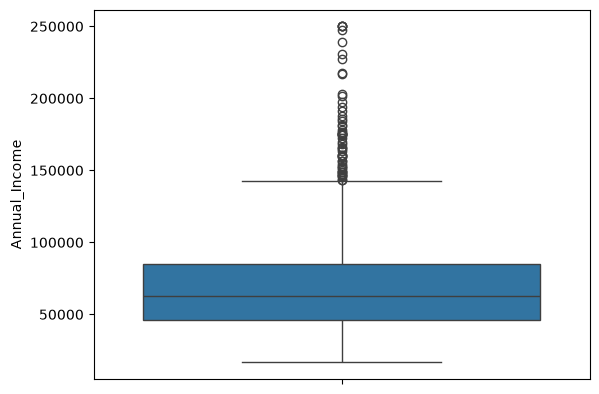

In [19]:
sns.boxplot(df["Annual_Income"])

<Axes: xlabel='Annual_Income', ylabel='Count'>

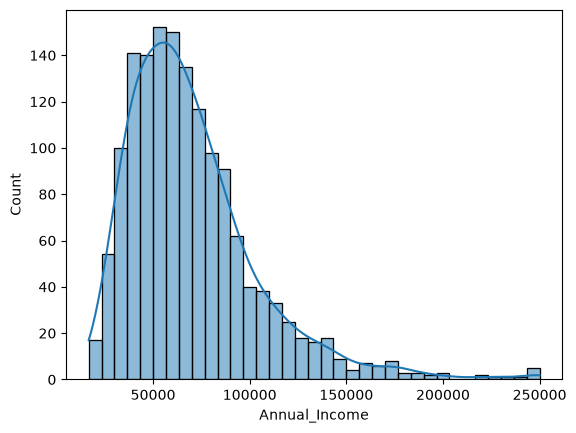

In [20]:
sns.histplot(df["Annual_Income"],kde=True)

<Axes: ylabel='Purchase_Amount'>

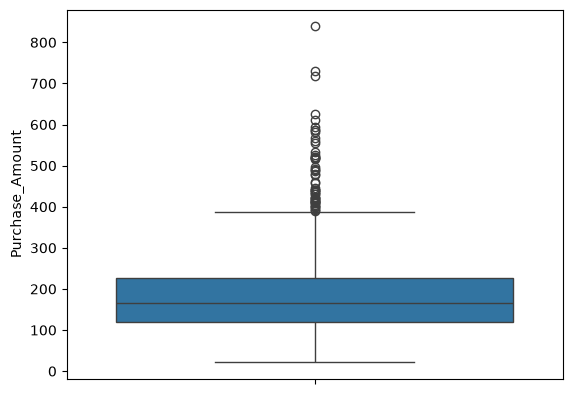

In [21]:
sns.boxplot(df["Purchase_Amount"])

<Axes: xlabel='Purchase_Amount', ylabel='Count'>

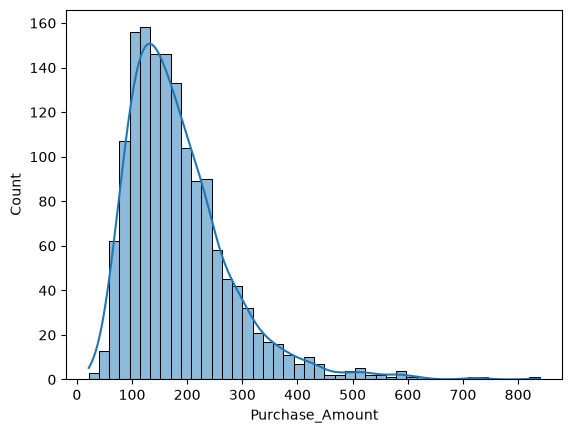

In [22]:
sns.histplot(df["Purchase_Amount"],kde=True)

<Axes: ylabel='Purchase_Frequency'>

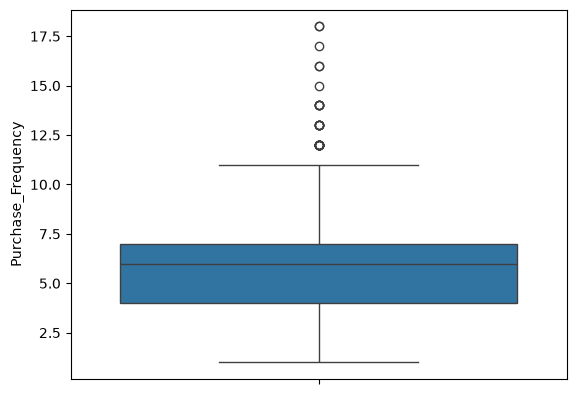

In [23]:
sns.boxplot(df["Purchase_Frequency"])

<Axes: xlabel='Purchase_Frequency', ylabel='Count'>

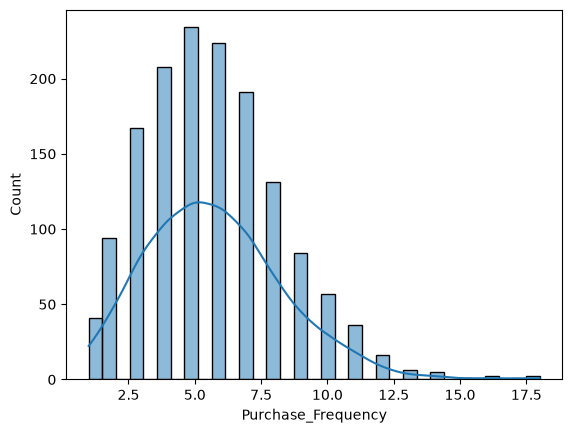

In [24]:
sns.histplot(df["Purchase_Frequency"],kde=True)

In [25]:
cols = ["Age", "Annual_Income", "Purchase_Amount", "Purchase_Frequency", "Customer_Rating"]
summary = df[cols].agg(["mean", "median", "std", "skew", "kurt"]).T
summary

,mean,median,std,skew,kurt
Age,38.020000,38.000,11.403199,0.186051,-0.406389
Annual_Income,70135.400000,63100.000,34173.004399,1.653640,4.296210
Purchase_Amount,184.329673,165.325,93.531508,1.720053,5.107267
Purchase_Frequency,5.748667,6.000,2.604231,0.657572,0.851101
Customer_Rating,3.475400,3.500,0.783103,-0.136220,-0.386719


Annual_Income and Purchase_Amount are highly skewed (above 1.5) and are not normally distributed.Purchase_Frequency has a moderate skeweness (0.66). Age and Customer_Rating are closer to a normal distribution.


### The number of outliers in Annual Income and Purchase Amount are higher with IQR than Z score because the distribution is skewed. I will not remove this values because they are likely to represent real high-income customers rather than data-entry error.

## Grouping people by their ages and comparing their data with eachother.

In [26]:
df["Age_Group"]=pd.cut(df["Age"],bins=[0,18,30,50,100],labels=["Teen","Young","Middle-aged","Senior"])

In [27]:
df.groupby("Age_Group")[["Purchase_Amount","Purchase_Frequency","Customer_Rating"]].mean()

,Purchase_Amount,Purchase_Frequency,Customer_Rating
Age_Group,,,
Teen,167.872840,5.814815,3.601235
Young,169.684921,5.492114,3.436278
Middle-aged,184.129518,5.717489,3.467825
Senior,213.634095,6.242857,3.518095


By this schedule we can see that the Seniors have the highest Purchase Amount and Purchase Frequency.

In [28]:
numeric_df=df.select_dtypes(include="number")

## Finding the correlation between variables.

In [29]:
corr=numeric_df.corr()
print(corr)

                         Age  Annual_Income  Purchase_Amount  \
Age                 1.000000       0.188907         0.152564   
Annual_Income       0.188907       1.000000         0.840501   
Purchase_Amount     0.152564       0.840501         1.000000   
Purchase_Frequency  0.072931       0.331033         0.457714   
Customer_Rating     0.015796       0.025740         0.050604   

                    Purchase_Frequency  Customer_Rating  
Age                           0.072931         0.015796  
Annual_Income                 0.331033         0.025740  
Purchase_Amount               0.457714         0.050604  
Purchase_Frequency            1.000000         0.171384  
Customer_Rating               0.171384         1.000000  


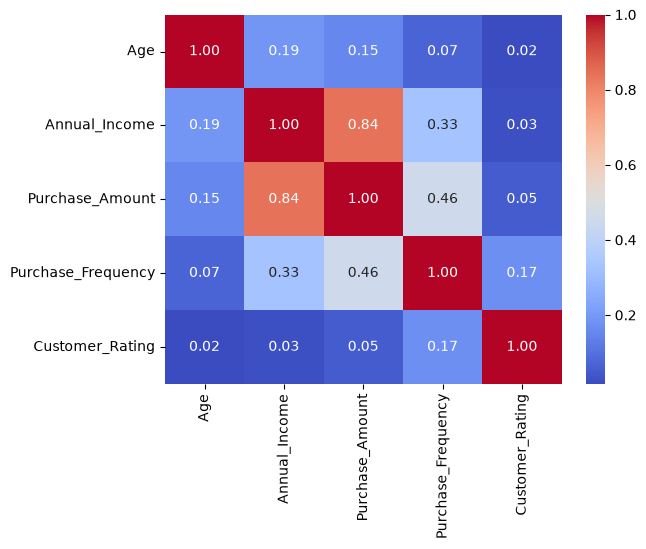

In [30]:
sns.heatmap(corr,annot=True,cmap="coolwarm",fmt=".2f")
plt.show()

## Finding the strongest correlation between variables.

In [31]:
corr_no_diag = corr.copy()

for i in range(len(corr_no_diag)):
    corr_no_diag.iloc[i, i] = 0

strongest = corr_no_diag.abs().stack().idxmax()

print(strongest)

('Annual_Income', 'Purchase_Amount')


In [32]:
print(corr_no_diag.loc[strongest])

0.8405010147321794


Because correlation coefficient is close to 1 we can say that Annual Income has a strong correlation with Purchase Amount.

In [33]:
group_a=df[df["Gender"]=="Male"]["Purchase_Amount"]
group_b=df[df["Gender"]=="Female"]["Purchase_Amount"]

In [34]:
from scipy.stats import shapiro

In [35]:
stat_a,p_a=shapiro(group_a)
stat_b,p_b=shapiro(group_b)

In [36]:
print(p_a)
print(p_b)

9.043774528798337e-23
1.649746324185091e-24


In [37]:
from scipy.stats import mannwhitneyu

In [38]:
result=mannwhitneyu(group_a,group_b)

In [39]:
n1, n2 = len(group_a), len(group_b)
u = result.statistic
r = 1 - (2*u) / (n1*n2)
print(r)

0.03173753536618118


In [40]:
print(result)

MannwhitneyuResult(statistic=np.float64(272242.0), pvalue=np.float64(0.28735806872841163))


Because neither group follows a normal distribution (shapiro p<0.05), I used mann-whitneyU test. The result (p>0.05) indicates that there is no statistically significant difference in purchase amounts between man and woman.

In [41]:
df["Income_Group"]=pd.qcut(df["Annual_Income"],q=3,labels=["low","medium","high"])

In [42]:
group_A=df[df["Income_Group"]=="low"]["Customer_Rating"]
group_B=df[df["Income_Group"]=="medium"]["Customer_Rating"]
group_C=df[df["Income_Group"]=="high"]["Customer_Rating"]

In [43]:
shapiro(group_A)

ShapiroResult(statistic=np.float64(0.9891674683195532), pvalue=np.float64(0.000926115643685294))

In [44]:
shapiro(group_B)

ShapiroResult(statistic=np.float64(0.9883822895856708), pvalue=np.float64(0.0005253937421303921))

In [45]:
shapiro(group_C)

ShapiroResult(statistic=np.float64(0.9893705964823826), pvalue=np.float64(0.0011132255383399397))

In [46]:
from scipy.stats import kruskal

In [47]:
result=kruskal(group_A,group_B,group_C)
print(result)

KruskalResult(statistic=np.float64(0.8783860713264711), pvalue=np.float64(0.6445563452584524))


In [48]:
n=len(df)
h=result.statistic
epsilon_sq=h/(n-1)
print(epsilon_sq)

0.0005859813684632896


Because neither group follows a normal distribution(shapiro p<0.05), I used kruskal-wallis test.The result(p>0.05)indicates that there is no statistically significant difference in those groups.

In [49]:
table=pd.crosstab(df["Gender"],df["Income_Group"])

In [50]:
from scipy.stats import chi2_contingency
chi2,p,dof,expected=chi2_contingency(table)
print(chi2,p)

3.8054002563937015 0.14916530951549797


Because the chi2 test results says that p is 0.149(p>0.05) so there is no relationship between gender and income group.

In [51]:
rng=np.random.default_rng(0)
diffs=[]
for i in range(2000):
    sample_a=rng.choice(group_a,len(group_a),replace=True)
    sample_b=rng.choice(group_b,len(group_b),replace=True)
    diffs.append(np.mean(sample_a)-np.mean(sample_b))

In [52]:
ci_low,ci_high=np.percentile(diffs,[2.5,97.5])

In [53]:
print(ci_low,ci_high)

-13.753667680600914 5.110134478180957


### «95% CI for the difference in means is [-13.8, 5.1], which includes zero — consistent with the Mann-Whitney result that there's no significant difference.»

#### In the next part I'll build a model that can predict the purchase income by using other features in the dataset.

In [54]:
from sklearn.model_selection import train_test_split
X=df[["Age","Annual_Income","Purchase_Frequency"]]
y=df["Purchase_Amount"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [55]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(X_train,y_train)
print(model.coef_)
print(model.intercept_)

[-3.86073228e-02  2.14162523e-03  7.14788187e+00]
-5.265614964403682


In [56]:
from sklearn.metrics import r2_score,mean_squared_error
y_pred=model.predict(X_test)
r2=r2_score(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
print("R2:", r2)
print("RMSE:" ,rmse)

R2: 0.7226992901860663
RMSE: 48.38527855256995


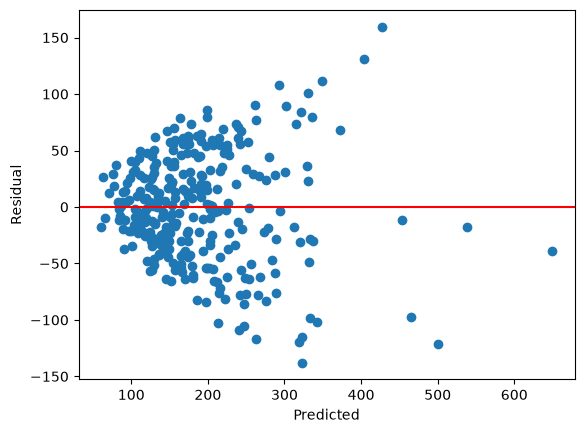

In [83]:
residuals=y_test-y_pred
plt.scatter(y_pred,residuals)
plt.axhline(0,color="red")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()

### This plot shows heteroscedasticity in the model: as the predicted value increases, the absolute residual grows instead of staying roughly constant.

In [58]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(random_state=0)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
r2_rf=r2_score(y_test,y_pred_rf)
rmse_rf=np.sqrt(mean_squared_error(y_test,y_pred_rf))
print("R2:",r2_rf)
print("RMSE:",rmse_rf)

R2: 0.6725758900290619
RMSE: 52.57667080884609


In [86]:
rf_model=RandomForestRegressor(random_state=0,max_depth=5)
rf_model.fit(X_train,y_train)
y_pred_rf=rf_model.predict(X_test)
r2_rf=r2_score(y_test,y_pred_rf)
rmse_rf=np.sqrt(mean_squared_error(y_pred_rf,y_test))
print("R2:",r2_rf)
print("RMSE:",rmse_rf)

R2: 0.7003588875324809
RMSE: 50.29657998860064


#### Limiting tree depth reduced overfitting (train R² dropped from 0.96 closer to test R²), improving test R² from 0.67 to 0.70, though still slightly below linear regression (0.72).

### Building a model to predict wether a customer is satisfied:

In [62]:
df["Satisfied"]=(df["Customer_Rating"]>=4).astype(int)
X_clf=df[["Age", "Annual_Income", "Purchase_Frequency", "Purchase_Amount"]]
y_clf=df["Satisfied"]
X_train_c,X_test_c,y_train_c,y_test_c=train_test_split(X_clf,y_clf,test_size=0.2,random_state=0)

In [65]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
scaler=StandardScaler()
X_train_c_scaled=scaler.fit_transform(X_train_c)
X_test_c_scaled=scaler.transform(X_test_c)
clf=LogisticRegression()
clf.fit(X_train_c_scaled,y_train_c)
y_pred_c=clf.predict(X_test_c_scaled)

In [87]:
from sklearn.metrics import confusion_matrix,precision_score,recall_score,roc_auc_score
print(confusion_matrix(y_test_c,y_pred_c))
print("Precision:",precision_score(y_test_c,y_pred_c))
print("Recall:",recall_score(y_test_c,y_pred_c))
auc = roc_auc_score(y_test_c, clf.predict_proba(X_test_c_scaled)[:, 1])
print("AUC:",auc)

[[221   2]
 [ 76   1]]
Precision: 0.3333333333333333
Recall: 0.012987012987012988
AUC: 0.6000232950905596


#### The model failed to identify satisfied customers (Recall≈0.01), consistent with Stage 3 findings that none of these variables have a meaningful relationship with Customer_Rating.

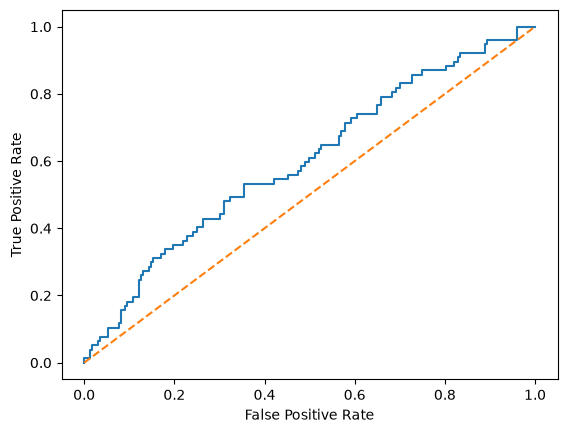

In [85]:
from sklearn.metrics import roc_curve
fpr,tpr,thresholds=roc_curve(y_test_c,clf.predict_proba(X_test_c_scaled)[:,1])
plt.plot(fpr,tpr)
plt.plot([0,1],[0,1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

### Finally, I'll segment customers into groups using K-Means clustering and the Elbow Method.

In [78]:
cluster_cols = ["Age", "Annual_Income", "Purchase_Amount", "Purchase_Frequency", "Customer_Rating"]
X_cluster=df[cluster_cols]
scaler2=StandardScaler()
X_cluster_scaled=scaler2.fit_transform(X_cluster)

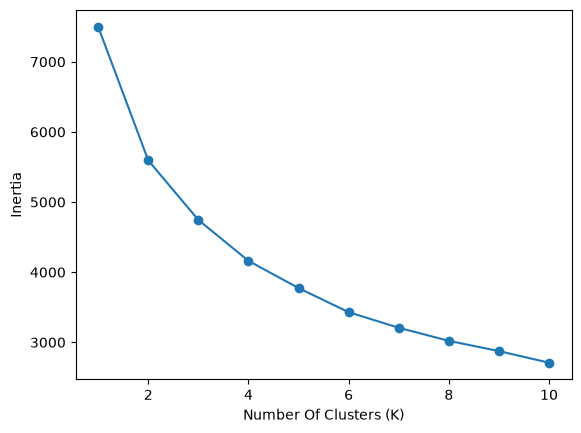

In [80]:
from sklearn.cluster import KMeans
inertia=[]
for k in range (1,11):
    km=KMeans(n_clusters=k,random_state=0)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)
plt.plot(range(1,11),inertia,marker="o")
plt.xlabel("Number Of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [81]:
kmeans_final=KMeans(n_clusters=4,random_state=0)
df["Cluster"]=kmeans_final.fit_predict(X_cluster_scaled)
df.groupby(["Cluster"])[cluster_cols].mean()

,Age,Annual_Income,Purchase_Amount,Purchase_Frequency,Customer_Rating
Cluster,,,,,
0,29.580931,50196.008869,126.841153,3.957871,3.097561
1,34.851759,64881.155779,182.884095,7.545226,4.115578
2,48.275000,66260.681818,164.514341,4.893182,3.302955
3,40.649289,130745.497630,351.255782,7.971564,3.435071


#### Cluster 3 stands out with the highest income and purchase amount, but only moderate satisfaction — suggesting high-value customers who may need extra attention.